## Text Data Generation, Analysis, and Efficiency Evaluation
In this part of the mini-project, you will develop a series of Python functions to **generate** and **analyze** **text data**, and then **evaluate the runtime efficiency** of the functions you have written. This task is divided into three main parts:

1. Data Generation (Part 1) – You will write a function to generate and store data in a text (.txt) file.
2. Data Analysis (Part 2) – You will implement functions to analyze the data from the txt file.
3. Efficiency Evaluation (Part 3) – You will assess the runtime efficiency of your data analysis functions.

In [1]:
import matplotlib.pyplot as plt
import random
import string
import time
import os

Matplotlib created a temporary config/cache directory at /tmp/matplotlib-67kd6san because the default path (/tmp/cache/matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


#### Part 1: Text Data Generation  
You will implement a function to **generate** a text file:  

- **`generateString`**: Generates a series of random **strings**, and writes them to a **text file**. Each string is generated by randomly selecting characters from the given alphabet (or a default of lowercase ASCII letters). The function should generate `linecount` strings, each with a length of `linelen`.

##### Notes:  
Carefully follow the suggested `random` functions and the exact string formatting specified, as the autograder requires an exact match for both.  

To assist with debugging, several example files have been provided, and a helper function, `compareFiles()`, is available to help you identify any mismatched lines.  

Example files are located in the `example/` directory. Your output files will be saved in the `data/` directory by default, so you can compare them directly.


In [2]:
# INPUT:
# f1, a string containing the file path to the first file being compared
# f2, a string containing the file path to the second file being compared
# OUTPUT:
# A boolean (True) if the files are identical and (False) otherwise.
# It also prints the first line pair which is not identical after whitespace is stripped
def compareFiles(f1, f2):
    with open(f1, 'r') as myf1:
        with open(f2, 'r') as myf2:
            f1_line = myf1.readline().strip()
            f2_line = myf2.readline().strip()
            while f1_line or f2_line:
                if f1_line != f2_line:
                    print("F1: {}".format(f1_line))
                    print("F2: {}".format(f2_line))
                    return False
                f1_line = myf1.readline().strip()
                f2_line = myf2.readline().strip()
    return True

#compareFiles("example1.csv", "example1.csv")

In [3]:
#grade

# generateString
# Generates a list of random strings, each of a specified length, and writes them to a text file.
# The strings are created by selecting one character at a time from the specified alphabet (or the default lowercase ASCII letters).
# The selection is done randomly with replacement, meaning characters can repeat within each string.
# To accomplish this, use the random.choice() function.
# 
# INPUT:
# fname (str): A required string specifying the name of the text file to be created (must end with ".txt").
# linelen (int): A required integer specifying the length of each string to generate.
# linecount (int): A required integer specifying how many strings to generate.
# charList (list of str, optional): A list of characters to use for generating strings. The default is the lowercase ASCII alphabet (a-z).
# seed (int, optional): A seed value for Python's random module to ensure reproducibility of the results. Default is None.
# 
# OUTPUT:
# None: The function creates a text file at the path specified by `fname`, where each line contains one randomly generated string.

def generateString(fname, linelen, linecount, charList=list(string.ascii_lowercase), seed=None):
    if seed:
        random.seed(seed)
    
    with open(fname, "w") as f:
        for i in range(linecount):
            random_string = "".join(random.choice(charList) for i in range(linelen))
            f.write(random_string + "\n")

In [4]:
# TEST generateString
# Compare with example/string/...

generateString("data/string/example1.txt", 5, 10, seed = 5)
generateString("data/string/example2.txt", 50, 2, ["T", "C", "G", "A"], seed = 5)
generateString('data/string/example3.txt', 8, 1000, ["0", "1"], seed=1)

#### Part 2: Data Analysis  
You will implement two functions to **analyze** the text file that you created in Part 1:  

- **`countUniqueStrings`**: Count how many unique strings are present in the file. Each line in the file is treated as an individual string.
- **`firstMatchingSubstring`**: Search through the file to find and return the index (0-based) of the first line that contains a specified substring.

Unlike in part 1, you have much more freedom of design here -- you can use pandas, numpy, or built-in methods to read in and process your files. **Just be sure the code you are submitting is your own work and no one elses!** The functions you are implementing here are meant to review your Python fundamentals, not your ability to use chatGPT.

In [5]:
#grade

# countUniqueStrings
# Counts the number of unique strings in a file, where each line is treated as a separate string.
#
# INPUT:
# fname (str): The name of the text file to read from (the file should end with .txt).
# OUTPUT:
# int: The total number of unique strings present in the file.

def countUniqueStrings(fname):
    unique = set()
    
    with open(fname, 'r') as f:
        for i in f:
            unique.add(i)

    return len(unique)

In [6]:
# TEST countUniqueStrings
print(countUniqueStrings('example/string/example1.txt')) #10
print(countUniqueStrings('example/string/example3.txt')) #252

10
252


In [7]:
#grade

# firstMatchingSubstring
# Searches for the first occurrence of a given substring in a text file.
# Returns the index (0-based) of the first line that contains the substring.
# If the substring is not found in any line, returns -1.
#
# INPUT:
# fname (str): The name of the text file to read from (must end in .txt).
# inStr (str): The substring to search for within each line of the file.
#
# OUTPUT:
# int: The 0-based index of the first matching line, or -1 if no match is found.

def firstMatchingSubstring(fname, inStr):
    with open(fname, "r") as f:
        for index, line in enumerate(f):
            if inStr in line:
                return index

    return -1

In [8]:
# TEST firstMatchingSubstring
print(firstMatchingSubstring('example/string/example1.txt', 'wxuqa')) # 1
print(firstMatchingSubstring('example/string/example1.txt', '10111')) # -1
print(firstMatchingSubstring('example/string/example3.txt', '10111')) #0

1
-1
0


#### Part 3: Runtime Efficiency Evaluation  

In this part, you will evaluate the runtime efficiency of the `firstMatchingSubstring` function from Part 2. You **must** complete Part 2 and pass the autograder before starting this part. Unlike previous parts, this section **will not be autograded** but will be **graded manually**.  

##### **Instructions**  

1. **Generate Text Files**  
   - Re-run the `firstMatchingSubstring` function with different values of `linecount` (e.g., `10, 100, 1000, 5000`).  
   - **Keep the following parameters fixed:**  
     - `linelen = 100`  
   - **Ensure that `linecount` does not exceed 100,000**, as PrairieLearn has limited storage capacity.  

2. **Measure Runtime Performance**  
   - For each experiment (one function run with a different `linecount` value):  
     - Generate a text file using `generateString`.  
     - Process the generated text file using `firstMatchingSubstring`.  
     - Record the function’s runtime and the corresponding `linecount` value.  

3. **Plot and Submit Results**  
   - Store the recorded runtime values and `linecount` values in two lists.  
   - Plot the relationship between `linecount` and runtime.  
   - Download the plot (as a PNG image) to your local computer.  
   - Upload the image to the **Part 3 submission folder** for grading.

In [48]:
# evaluateRuntime: Evaluates the runtime of the generateString function for different values of linecount.

# INPUT:
# linecounts (list of int): A list of `linecount` values to test.
# fname (str, optional): The name of the text file to be generated and tested. Default is "test_file.txt".
# inStr (str, optional): The string to search for in the generated text file. Default is 'abc'.

# OUTPUT:
# List of rowcount values used in the experiments.
# Corresponding runtimes (in seconds) for each rowcount value.

def evaluateRuntime(linecounts, fname="test_file.txt", inStr='abc'):
    runtimes = []
    
    for linecount in linecounts:
        generateString(fname, linelen=100, linecount=linecount)
        
        start = time.time()
        firstMatchingSubstring(fname, inStr)
        end = time.time()       

        runtime = end - start
        runtimes.append(runtime) 
        
    return linecounts, runtimes

In [58]:
# TEST evaluateRuntime
linecounts = [10000, 30000, 50000, 70000, 90000]
linecounts_used, runtimes = evaluateRuntime(linecounts, fname="test_file.txt", inStr='abc')

In [59]:
def plotRuntime(linecounts_used, runtimes):
    plt.figure(figsize=(10, 5))  # Set figure size
    plt.plot(linecounts_used, runtimes, marker="o", linestyle="-", label="Runtime (seconds)")

    plt.xlabel("Number of lines (linecount)")
    plt.ylabel("Execution Time (seconds)")
    plt.title("Runtime of firstMatchingSubstring")
    plt.legend()

    plt.savefig("runtime_plot_string.png")

    plt.show()

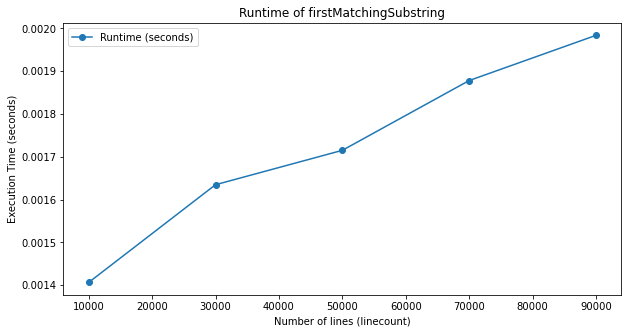

In [60]:
# TEST plotRuntime and SAVE PLOT
plotRuntime(linecounts, runtimes)